In [1]:
import numpy as np

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/European_Bank.csv")

In [4]:
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.shape

(10000, 14)

In [6]:
df.columns

Index(['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [8]:
df.describe()

,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [9]:
df.isnull().sum()

Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
print(df['HasCrCard'].unique())
print(df['IsActiveMember'].unique())
print(df['Exited'].unique())

[1 0]
[1 0]
[1 0]


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
print(df['Geography'].unique())
print(df['Gender'].unique())

<ArrowStringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str
<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str


In [14]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [15]:
df['Exited'].value_counts(normalize=True) * 100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

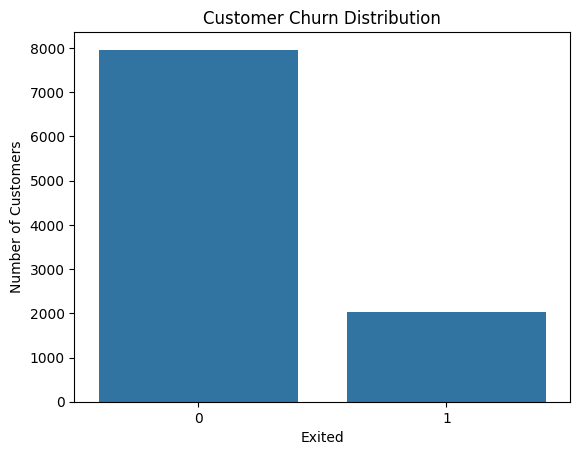

In [16]:
sns.countplot(x='Exited', data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Exited")
plt.ylabel("Number of Customers")

plt.show()

In [17]:
churn_rate = df['Exited'].mean() * 100
print("Churn Rate:", churn_rate)

Churn Rate: 20.369999999999997


In [18]:
def classify_customer(row):

    if row['IsActiveMember'] == 1 and row['NumOfProducts'] >= 2:
        return 'Active Engaged'

    elif row['IsActiveMember'] == 0 and row['NumOfProducts'] == 1:
        return 'Inactive Disengaged'

    elif row['IsActiveMember'] == 1 and row['NumOfProducts'] == 1:
        return 'Active Low Product'

    elif row['IsActiveMember'] == 0 and row['Balance'] > 100000:
        return 'Inactive High Balance'

    else:
        return 'Moderate Engagement'


df['EngagementSegment'] = df.apply(classify_customer, axis=1)

In [19]:
df['EngagementSegment'].value_counts()

EngagementSegment
Active Engaged           2588
Active Low Product       2563
Inactive Disengaged      2521
Moderate Engagement      1549
Inactive High Balance     779
Name: count, dtype: int64

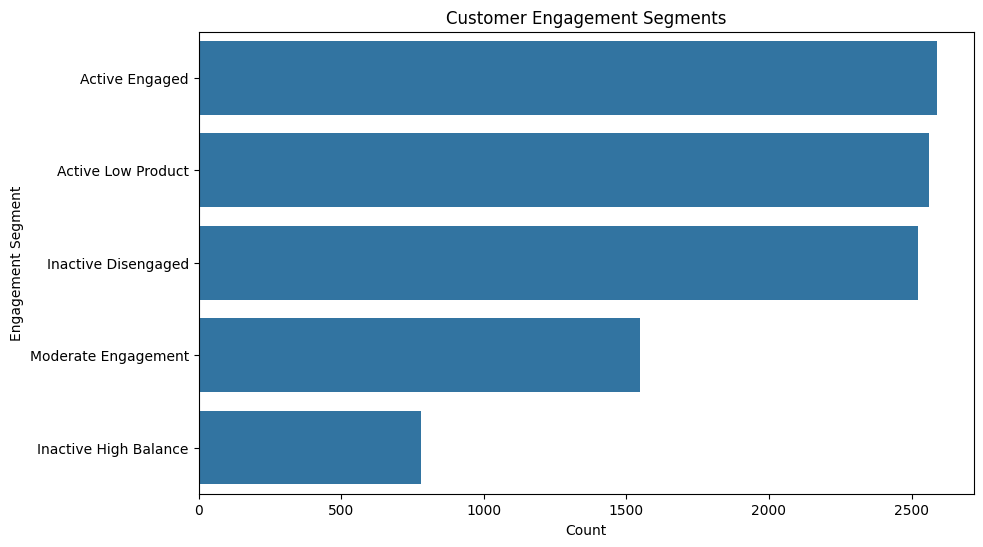

In [20]:
plt.figure(figsize=(10,6))

sns.countplot(
    y='EngagementSegment',
    data=df,
    order=df['EngagementSegment'].value_counts().index
)

plt.title("Customer Engagement Segments")
plt.xlabel("Count")
plt.ylabel("Engagement Segment")

plt.show()

In [21]:
product_churn = df.groupby('NumOfProducts')['Exited'].mean() * 100

print(product_churn)

NumOfProducts
1     27.714398
2      7.581699
3     82.706767
4    100.000000
Name: Exited, dtype: float64


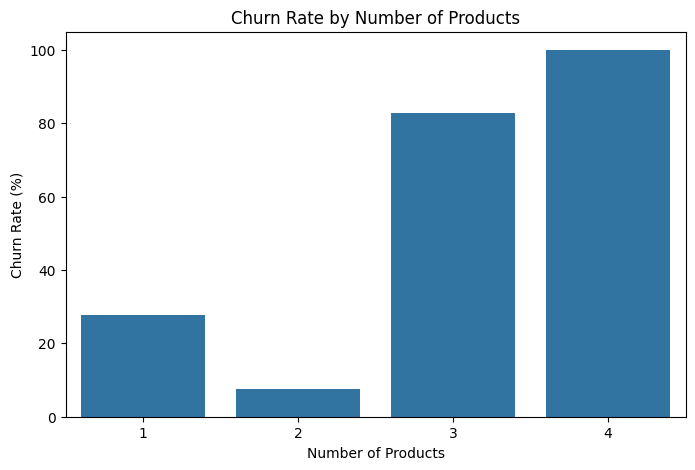

In [22]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=product_churn.index,
    y=product_churn.values
)

plt.title("Churn Rate by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")

plt.show()

In [23]:
df['ProductCategory'] = df['NumOfProducts'].apply(
    lambda x: 'Single Product' if x == 1 else 'Multi Product'
)

In [24]:
product_category_churn = df.groupby('ProductCategory')['Exited'].mean() * 100

print(product_category_churn)

ProductCategory
Multi Product     12.774614
Single Product    27.714398
Name: Exited, dtype: float64


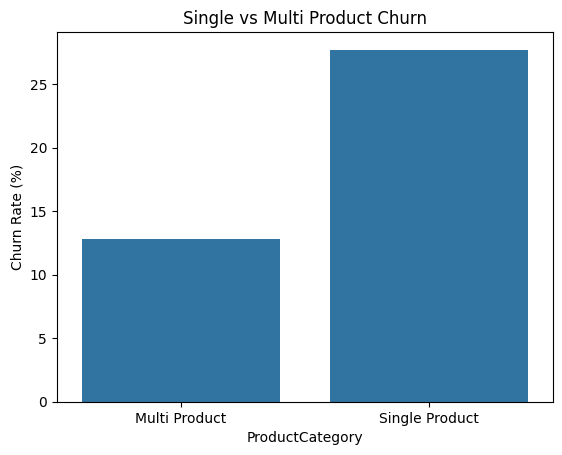

In [25]:
sns.barplot(
    x=product_category_churn.index,
    y=product_category_churn.values
)

plt.title("Single vs Multi Product Churn")
plt.ylabel("Churn Rate (%)")

plt.show()

In [26]:
balance_activity = df.groupby('IsActiveMember')['Balance'].mean()

print(balance_activity)

IsActiveMember
0    77134.376863
1    75875.422145
Name: Balance, dtype: float64


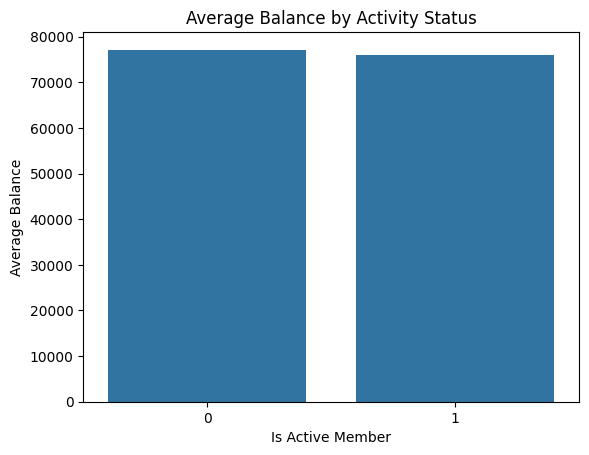

In [27]:
sns.barplot(
    x=balance_activity.index,
    y=balance_activity.values
)

plt.title("Average Balance by Activity Status")
plt.xlabel("Is Active Member")
plt.ylabel("Average Balance")

plt.show()

In [28]:
df['HighValueCustomer'] = df['Balance'].apply(
    lambda x: 1 if x > 100000 else 0
)

In [29]:
inactive_high_value = df[
    (df['HighValueCustomer'] == 1) &
    (df['IsActiveMember'] == 0)
]

inactive_high_value.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,EngagementSegment,ProductCategory,HighValueCustomer
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Inactive High Balance,Multi Product,1
5,2025,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1,Inactive High Balance,Multi Product,1
7,2025,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1,Inactive High Balance,Multi Product,1
10,2025,15767821,Bearce,528,France,Male,31,6,102016.72,2,0,0,80181.12,0,Inactive High Balance,Multi Product,1
16,2025,15737452,Romeo,653,Germany,Male,58,1,132602.88,1,1,0,5097.67,1,Inactive Disengaged,Single Product,1


In [30]:
inactive_high_value.shape

(2356, 17)

In [31]:
high_value_churn = df.groupby('HighValueCustomer')['Exited'].mean() * 100

print(high_value_churn)

HighValueCustomer
0    15.881561
1    25.234424
Name: Exited, dtype: float64


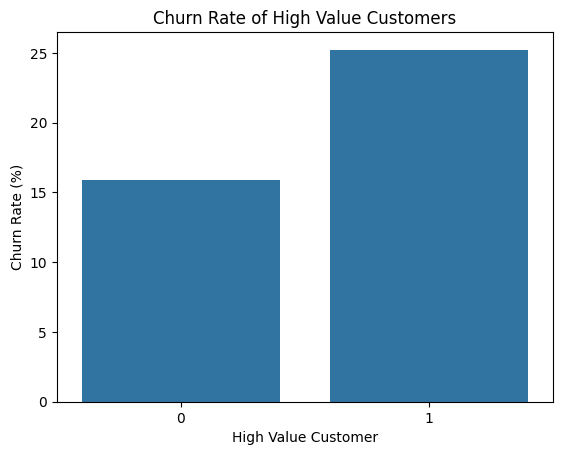

In [32]:
sns.barplot(
    x=high_value_churn.index,
    y=high_value_churn.values
)

plt.title("Churn Rate of High Value Customers")
plt.xlabel("High Value Customer")
plt.ylabel("Churn Rate (%)")

plt.show()

In [33]:
df['SalaryBalanceRatio'] = df['EstimatedSalary'] / (df['Balance'] + 1)

In [34]:
salary_balance_risk = df[
    (df['EstimatedSalary'] > 150000) &
    (df['Balance'] < 50000) &
    (df['IsActiveMember'] == 0)
]

salary_balance_risk.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,EngagementSegment,ProductCategory,HighValueCustomer,SalaryBalanceRatio
13,2025,15691483,Chin,549,France,Female,25,5,0.0,2,0,0,190857.79,0,Moderate Engagement,Multi Product,0,190857.79
18,2025,15661507,Muldrow,587,Spain,Male,45,6,0.0,1,0,0,158684.81,0,Inactive Disengaged,Single Product,0,158684.81
87,2025,15625759,Rowley,729,France,Male,30,9,0.0,2,1,0,151869.35,0,Moderate Engagement,Multi Product,0,151869.35
101,2025,15743192,Hung,623,France,Female,44,6,0.0,2,0,0,167162.43,0,Moderate Engagement,Multi Product,0,167162.43
124,2025,15779659,Zetticci,625,France,Female,28,3,0.0,1,0,0,183646.41,0,Inactive Disengaged,Single Product,0,183646.41


In [35]:
salary_balance_risk.shape

(439, 18)

In [36]:
segment_churn = df.groupby('EngagementSegment')['Exited'].mean() * 100

print(segment_churn)

EngagementSegment
Active Engaged            9.659969
Active Low Product       18.923137
Inactive Disengaged      36.652122
Inactive High Balance    27.599487
Moderate Engagement      10.522918
Name: Exited, dtype: float64


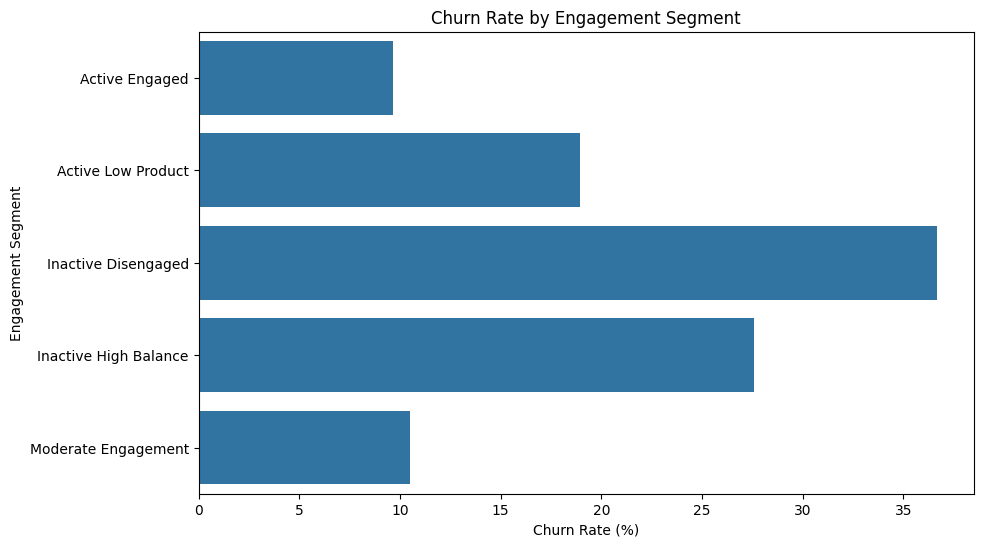

In [37]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=segment_churn.values,
    y=segment_churn.index
)

plt.title("Churn Rate by Engagement Segment")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Engagement Segment")

plt.show()

In [38]:
df['StickyCustomer'] = df.apply(
    lambda row: 1 if (
        row['IsActiveMember'] == 1 and
        row['NumOfProducts'] >= 2 and
        row['Balance'] > 50000
    )
    else 0,
    axis=1
)

In [39]:
df['StickyCustomer'].value_counts()

StickyCustomer
0    8866
1    1134
Name: count, dtype: int64

In [40]:
sticky_churn = df.groupby('StickyCustomer')['Exited'].mean() * 100

print(sticky_churn)

StickyCustomer
0    20.922626
1    16.049383
Name: Exited, dtype: float64


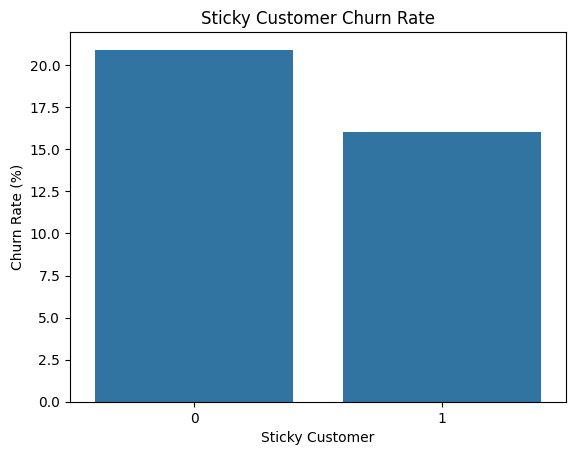

In [41]:
sns.barplot(
    x=sticky_churn.index,
    y=sticky_churn.values
)

plt.title("Sticky Customer Churn Rate")
plt.xlabel("Sticky Customer")
plt.ylabel("Churn Rate (%)")

plt.show()

# KPI Metrics Analysis

In [42]:
engagement_retention = df.groupby('IsActiveMember')['Exited'].mean() * 100

print(engagement_retention)

IsActiveMember
0    26.850897
1    14.269074
Name: Exited, dtype: float64


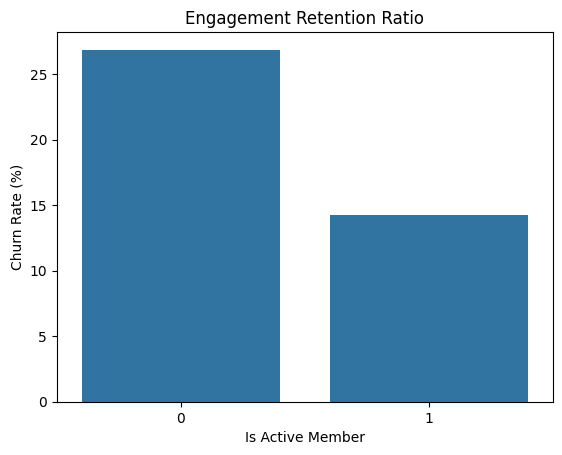

In [43]:
sns.barplot(
    x=engagement_retention.index,
    y=engagement_retention.values
)

plt.title("Engagement Retention Ratio")
plt.xlabel("Is Active Member")
plt.ylabel("Churn Rate (%)")

plt.show()

### Insight:
Inactive customers show significantly higher churn rates compared to active customers, indicating that engagement strongly influences retention.

In [44]:
product_depth = df.groupby('NumOfProducts')['Exited'].mean() * 100

print(product_depth)

NumOfProducts
1     27.714398
2      7.581699
3     82.706767
4    100.000000
Name: Exited, dtype: float64


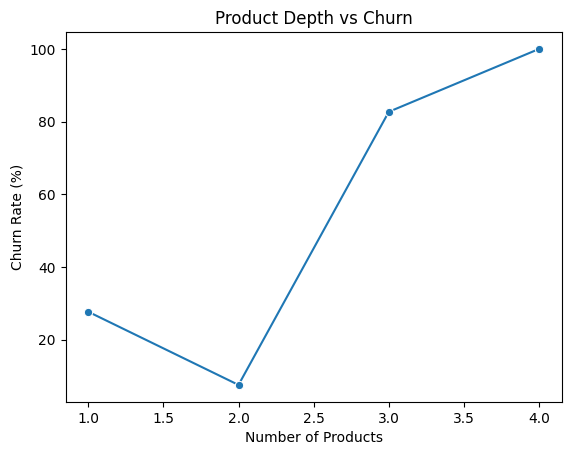

In [45]:
sns.lineplot(
    x=product_depth.index,
    y=product_depth.values,
    marker='o'
)

plt.title("Product Depth vs Churn")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")

plt.show()

In [46]:
high_balance_disengaged = df[
    (df['Balance'] > 100000) &
    (df['IsActiveMember'] == 0)
]

rate = (
    high_balance_disengaged['Exited'].mean()
) * 100

print("High-Balance Disengagement Churn Rate:", round(rate,2), "%")

High-Balance Disengagement Churn Rate: 32.77 %


In [47]:
card_stickiness = df.groupby('HasCrCard')['Exited'].mean() * 100

print(card_stickiness)

HasCrCard
0    20.814941
1    20.184266
Name: Exited, dtype: float64


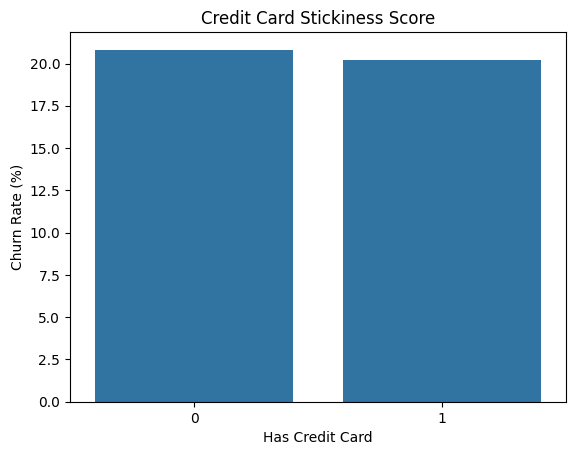

In [48]:
sns.barplot(
    x=card_stickiness.index,
    y=card_stickiness.values
)

plt.title("Credit Card Stickiness Score")
plt.xlabel("Has Credit Card")
plt.ylabel("Churn Rate (%)")

plt.show()

In [49]:
df['RelationshipStrength'] = (
    df['NumOfProducts'] * 2 +
    df['IsActiveMember'] * 3 +
    df['HasCrCard'] * 1
)

In [50]:
relationship_churn = df.groupby(
    'RelationshipStrength'
)['Exited'].mean() * 100

print(relationship_churn)

RelationshipStrength
2      34.540390
3      37.493067
4      10.426540
5      13.745107
6      19.383260
7      17.496962
8       5.676606
9      85.964912
10     74.358974
11    100.000000
12    100.000000
Name: Exited, dtype: float64


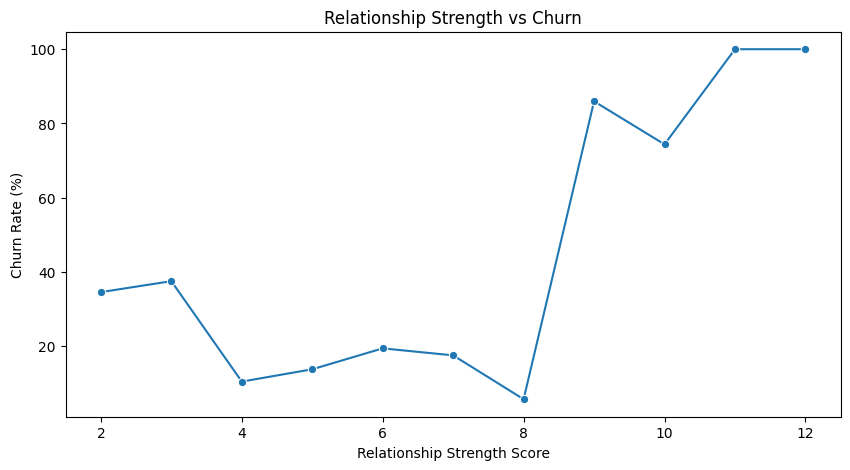

In [51]:
plt.figure(figsize=(10,5))

sns.lineplot(
    x=relationship_churn.index,
    y=relationship_churn.values,
    marker='o'
)

plt.title("Relationship Strength vs Churn")
plt.xlabel("Relationship Strength Score")
plt.ylabel("Churn Rate (%)")

plt.show()

# Final Insights & Business Recommendations

In [52]:
df.to_csv("final_customer_analysis.csv", index=False)

In [53]:
engagement_churn = pd.crosstab(
    df['IsActiveMember'],
    df['Exited'],
    normalize='index'
) * 100

engagement_churn

Exited,0,1
IsActiveMember,,
0,73.149103,26.850897
1,85.730926,14.269074


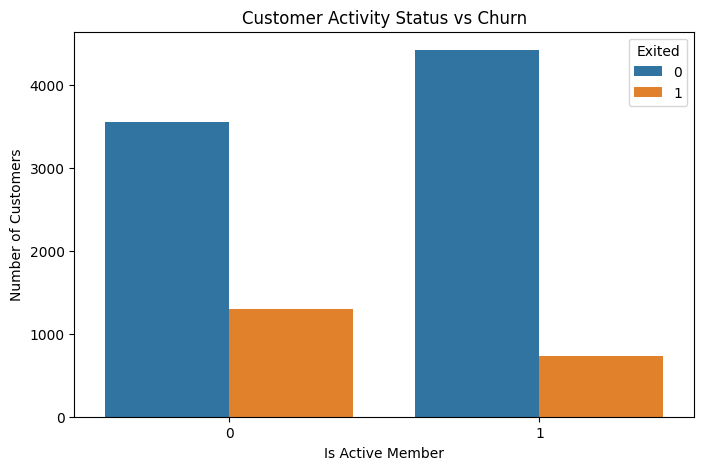

In [54]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='IsActiveMember',
    hue='Exited',
    data=df
)

plt.title("Customer Activity Status vs Churn")
plt.xlabel("Is Active Member")
plt.ylabel("Number of Customers")

plt.show()

### Insight: Customer Activity vs Churn

Inactive customers show a significantly higher churn rate compared to active customers. This indicates that customer engagement plays a major role in customer retention.

Customers who actively interact with the bank’s services are more likely to remain loyal, while inactive customers are at a higher risk of leaving the bank.

Business Recommendation:
The bank should implement targeted engagement campaigns, personalized offers, and proactive communication strategies to re-engage inactive customers and reduce churn risk.

In [55]:
product_churn = pd.crosstab(
    df['NumOfProducts'],
    df['Exited'],
    normalize='index'
) * 100

product_churn

Exited,0,1
NumOfProducts,,
1,72.285602,27.714398
2,92.418301,7.581699
3,17.293233,82.706767
4,0.000000,100.000000


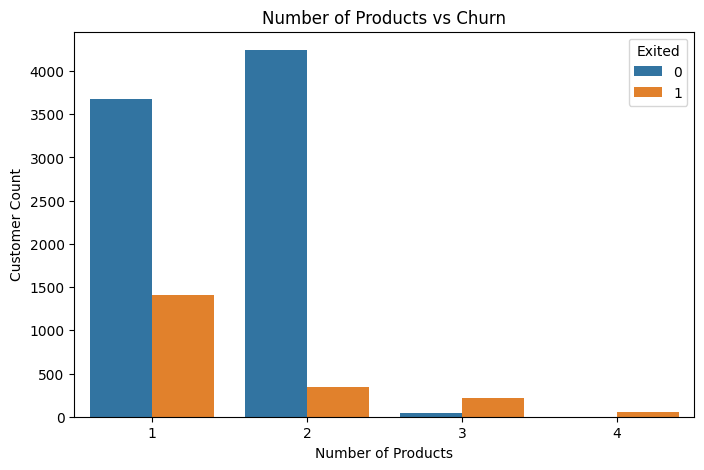

In [56]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='NumOfProducts',
    hue='Exited',
    data=df
)

plt.title("Number of Products vs Churn")
plt.xlabel("Number of Products")
plt.ylabel("Customer Count")

plt.show()

### Insight: Product Utilization vs Churn

Customers with only one banking product show significantly higher churn levels compared to customers using two products. This suggests that moderate product adoption strengthens customer relationships and improves retention.

Interestingly, customers with three or four products also show elevated churn levels. This may indicate that excessive product complexity or unmet expectations among highly engaged customers could contribute to dissatisfaction.

Business Recommendation:
The bank should encourage customers to adopt additional relevant products to strengthen engagement, while also ensuring that high-product customers receive personalized support and relationship management.

In [57]:
high_balance_customers = df[df['Balance'] > df['Balance'].median()]

high_balance_customers.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,EngagementSegment,ProductCategory,HighValueCustomer,SalaryBalanceRatio,StickyCustomer,RelationshipStrength
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Inactive High Balance,Multi Product,1,0.713581,0,7
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Active Low Product,Single Product,1,0.630093,0,6
5,2025,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1,Inactive High Balance,Multi Product,1,1.316464,0,5
7,2025,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1,Inactive High Balance,Multi Product,1,1.037368,0,9
8,2025,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0,Active Engaged,Multi Product,1,0.527557,1,7


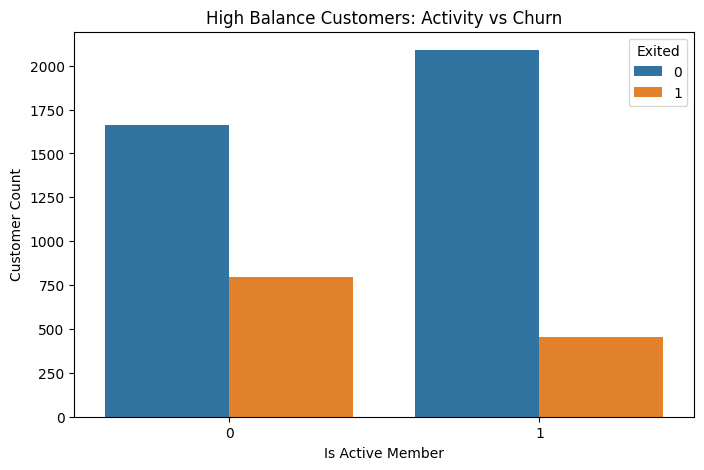

In [58]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='IsActiveMember',
    hue='Exited',
    data=high_balance_customers
)

plt.title("High Balance Customers: Activity vs Churn")
plt.xlabel("Is Active Member")
plt.ylabel("Customer Count")

plt.show()

In [59]:
active_retention = (
    df[df['IsActiveMember'] == 1]['Exited']
    .value_counts(normalize=True)[0]
) * 100

inactive_retention = (
    df[df['IsActiveMember'] == 0]['Exited']
    .value_counts(normalize=True)[0]
) * 100

print("Active Customer Retention Rate:", round(active_retention, 2), "%")
print("Inactive Customer Retention Rate:", round(inactive_retention, 2), "%")

Active Customer Retention Rate: 85.73 %
Inactive Customer Retention Rate: 73.15 %


In [60]:
engagement_retention_ratio = (
    active_retention / inactive_retention
)

print("Engagement Retention Ratio:",
      round(engagement_retention_ratio, 2))

Engagement Retention Ratio: 1.17


In [61]:
retained_customers = df[df['Exited'] == 0]

product_depth_index = retained_customers['NumOfProducts'].mean()

print("Product Depth Index:",
      round(product_depth_index, 2))

Product Depth Index: 1.54


In [62]:
df['RelationshipStrengthScore'] = (
    df['IsActiveMember'] * 3 +
    df['NumOfProducts'] * 2 +
    df['HasCrCard'] * 1
)

In [63]:
relationship_strength_index = (
    df['RelationshipStrengthScore'].mean()
)

print(
    "Relationship Strength Index:",
    round(relationship_strength_index, 2)
)

Relationship Strength Index: 5.31


In [64]:
df.groupby('Exited')[
    'RelationshipStrengthScore'
].mean()

Exited
0    5.459375
1    4.731959
Name: RelationshipStrengthScore, dtype: float64

In [65]:
conditions = [
    (
        (df['IsActiveMember'] == 1) &
        (df['NumOfProducts'] >= 2)
    ),

    (
        (df['IsActiveMember'] == 0) &
        (df['NumOfProducts'] <= 1)
    ),

    (
        (df['Balance'] > df['Balance'].median()) &
        (df['IsActiveMember'] == 0)
    )
]

segments = [
    'Loyal Customers',
    'At-Risk Customers',
    'Premium At-Risk'
]

df['CustomerSegment'] = np.select(
    conditions,
    segments,
    default='Moderate Customers'
)

In [66]:
df['CustomerSegment'].value_counts()

CustomerSegment
Moderate Customers    4078
Loyal Customers       2588
At-Risk Customers     2521
Premium At-Risk        813
Name: count, dtype: int64

In [67]:
segment_churn = pd.crosstab(
    df['CustomerSegment'],
    df['Exited'],
    normalize='index'
) * 100

segment_churn

Exited,0,1
CustomerSegment,,
At-Risk Customers,63.347878,36.652122
Loyal Customers,90.340031,9.659969
Moderate Customers,84.232467,15.767533
Premium At-Risk,72.939729,27.060271


In [68]:
conditions = [
    (
        (df['IsActiveMember'] == 1) &
        (df['NumOfProducts'] >= 2)
    ),

    (
        (df['IsActiveMember'] == 0) &
        (df['NumOfProducts'] <= 1)
    ),

    (
        (df['Balance'] > df['Balance'].median()) &
        (df['IsActiveMember'] == 0)
    )
]

segments = [
    'Loyal Customers',
    'At-Risk Customers',
    'Premium At-Risk'
]

df['CustomerSegment'] = np.select(
    conditions,
    segments,
    default='Moderate Customers'
)

In [69]:
df['CustomerSegment'].value_counts()

CustomerSegment
Moderate Customers    4078
Loyal Customers       2588
At-Risk Customers     2521
Premium At-Risk        813
Name: count, dtype: int64

In [70]:
segment_churn = pd.crosstab(
    df['CustomerSegment'],
    df['Exited'],
    normalize='index'
) * 100

segment_churn

Exited,0,1
CustomerSegment,,
At-Risk Customers,63.347878,36.652122
Loyal Customers,90.340031,9.659969
Moderate Customers,84.232467,15.767533
Premium At-Risk,72.939729,27.060271


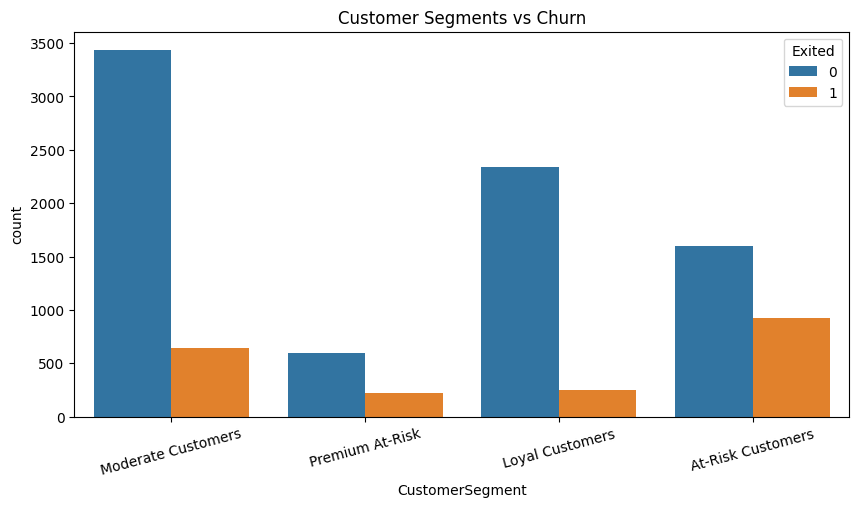

In [71]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='CustomerSegment',
    hue='Exited',
    data=df
)

plt.title("Customer Segments vs Churn")
plt.xticks(rotation=15)

plt.show()

# Initial Observations
- Dataset contains 10,000 rows and 14 columns
- Dataset contains customer banking information
- Customers belong to different countries
- Balance values vary significantly
- Some customers have zero balance